# Configs

In [1]:
League_Name = "Imaginary_Hammers"

In [2]:
# Seasons
Season_list = [
    "Season_0_2025",
    "Season_m1_2024",
    "Season_m2_2023",
    "Season_m3_2022",
    "Season_m4_2021"
]

In [3]:
#Scoring Categories
Scoring_Categories_Batting = [
    "R",
    "HR",
    "OBP",
    "SLG"
]
Scoring_Categories_Pitching = [
    "K",
    "HR9",
    "ERA",
    "WHIP"
]
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [4]:
import pandas as pd
import os
curr_path = os.path.abspath("/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects")
Team_Ranks_df = pd.DataFrame()
for season in Season_list:
    temp_df = pd.read_csv(f"{curr_path}/{League_Name}/{season}/Team_Ranks.csv")
    temp_df['Season'] = season
    Team_Ranks_df = pd.concat([Team_Ranks_df, temp_df], ignore_index=True)
Team_Statistics_df = pd.DataFrame()
for season in Season_list:
    temp_df = pd.read_csv(f"{curr_path}/{League_Name}/{season}/Team_Statistics.csv")
    temp_df['Season'] = season
    Team_Statistics_df = pd.concat([Team_Statistics_df, temp_df], ignore_index=True)

# Historical Final Standings

In [5]:
Team_Ranks_df['Place'] = Team_Ranks_df.groupby('Season')["TOTAL"].rank(method="dense", ascending=False)

In [6]:
Team_Ranks_df.head()

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,0.0,Season_0_2025,2.0
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,1.0,Season_0_2025,3.0
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,0.0,Season_0_2025,4.0
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,0.0,Season_0_2025,5.0


In [7]:
Team_Ranks_df[Team_Ranks_df['Place'] == 1]

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0
12,St. CGT VI,12.0,12.0,12.0,12.0,12.0,11.0,9.0,11.0,91.0,1.0,Season_m1_2024,1.0
24,St. CGT VI,12.0,10.0,11.0,11.0,12.0,12.0,11.0,11.0,90.0,0.0,Season_m2_2023,1.0
36,The Rime of Jamie Moyer,12.0,10.0,12.0,11.0,11.0,11.0,12.0,12.0,91.0,0.0,Season_m3_2022,1.0
48,St. CGT VI,11.0,8.0,12.0,6.0,12.0,12.0,11.0,11.0,83.0,0.0,Season_m4_2021,1.0


In [8]:
Team_Ranks_df= Team_Ranks_df.merge(Team_Ranks_df.groupby('Place')['TOTAL'].mean().reset_index(name='Mean'))
Team_Ranks_df = Team_Ranks_df.merge(Team_Ranks_df.groupby('Place')['TOTAL'].std().reset_index(name='Std'))

In [9]:
Team_Ranks_df[Team_Ranks_df['Place'] == 1]

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place,Mean,Std
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0,87.0,5.147815
12,St. CGT VI,12.0,12.0,12.0,12.0,12.0,11.0,9.0,11.0,91.0,1.0,Season_m1_2024,1.0,87.0,5.147815
24,St. CGT VI,12.0,10.0,11.0,11.0,12.0,12.0,11.0,11.0,90.0,0.0,Season_m2_2023,1.0,87.0,5.147815
36,The Rime of Jamie Moyer,12.0,10.0,12.0,11.0,11.0,11.0,12.0,12.0,91.0,0.0,Season_m3_2022,1.0,87.0,5.147815
48,St. CGT VI,11.0,8.0,12.0,6.0,12.0,12.0,11.0,11.0,83.0,0.0,Season_m4_2021,1.0,87.0,5.147815


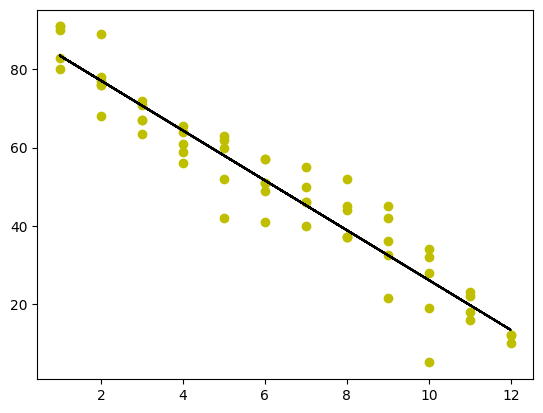

In [10]:
import numpy as np
import matplotlib.pyplot as plt

coef = np.polyfit(Team_Ranks_df['Place'],Team_Ranks_df['TOTAL'],1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(Team_Ranks_df['Place'],Team_Ranks_df['TOTAL'], 'yo', Team_Ranks_df['Place'], poly1d_fn(Team_Ranks_df['Place']), '--k')

In [11]:
print(Team_Ranks_df['Place'].unique())
print(poly1d_fn(Team_Ranks_df['Place'].unique()))
print(poly1d_fn(Team_Ranks_df['Place'].unique())/len(Scoring_Categories))
Avg_cat_pts_win = poly1d_fn(1.)/len(Scoring_Categories)
print('Target Rank Each Category:', Avg_cat_pts_win)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
[83.529033   77.14722599 70.76541898 64.38361197 58.00180496 51.61999795
 45.23819094 38.85638393 32.47457692 26.09276991 19.7109629  13.32915589]
[10.44112913  9.64340325  8.84567737  8.0479515   7.25022562  6.45249974
  5.65477387  4.85704799  4.05932212  3.26159624  2.46387036  1.66614449]
Target Rank Each Category: 10.441129125169613


In [12]:
Team_Ranks_df.head()

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place,Mean,Std
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0,87.000000,5.147815
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,0.0,Season_0_2025,2.0,77.333333,6.742897
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,1.0,Season_0_2025,3.0,68.100000,3.435113
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,0.0,Season_0_2025,4.0,61.100000,3.814446
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,0.0,Season_0_2025,5.0,55.800000,8.843076


In [13]:
Points_Needed = pd.DataFrame({'Place':Team_Ranks_df['Place'].unique(), 'Points_Needed':poly1d_fn(Team_Ranks_df['Place'].unique())})

In [14]:
Points_Needed

,Place,Points_Needed
0,1.0,83.529033
1,2.0,77.147226
2,3.0,70.765419
3,4.0,64.383612
4,5.0,58.001805
5,6.0,51.619998
6,7.0,45.238191
7,8.0,38.856384
8,9.0,32.474577
9,10.0,26.092770


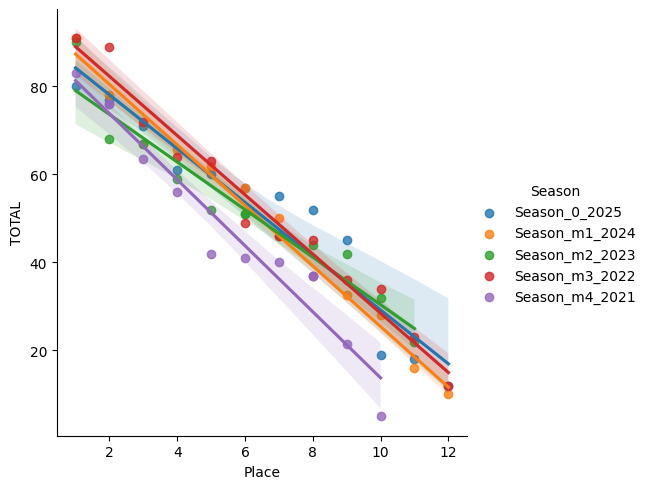

In [15]:
import seaborn as sns
sns.lmplot(data=Team_Ranks_df, x="Place", y="TOTAL", hue='Season')

# Historical Scoring categories

In [16]:
Team_Statistics_df.head()

,TEAM,G,R,HR,OBP,SLG,IP,K,HR9,ERA,WHIP,Season
0,St. CGT VI,1944,1062,306,0.34046,0.43600,1475.2,1632,1.01852,3.45810,1.14660,Season_0_2025
1,The Rime of Jamie Moyer,1889,1118,359,0.33645,0.46971,1499.2,1509,1.12225,3.61880,1.18293,Season_0_2025
2,Hornswogglers,1931,1067,313,0.33533,0.44238,1505.0,1619,1.05847,3.77342,1.21595,Season_0_2025
3,Largely Indistinguishables,1806,942,220,0.32933,0.41728,1500.0,1694,0.90000,2.87400,1.07600,Season_0_2025
4,Carlos Pérez's K-Dance,1765,955,297,0.31807,0.43939,1262.2,1252,0.84820,3.14335,1.16816,Season_0_2025


In [17]:
Team_Statistics_df['Team'] = Team_Statistics_df['TEAM']

In [18]:
Team_Ranks_df.head()

,Team,R,HR,OBP,SLG,K,HR9,ERA,WHIP,TOTAL,CHG,Season,Place,Mean,Std
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,0.0,Season_0_2025,1.0,87.000000,5.147815
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,0.0,Season_0_2025,2.0,77.333333,6.742897
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,1.0,Season_0_2025,3.0,68.100000,3.435113
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,0.0,Season_0_2025,4.0,61.100000,3.814446
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,0.0,Season_0_2025,5.0,55.800000,8.843076


In [19]:
Stat_Ranks = Team_Ranks_df.merge(Team_Statistics_df,on=['Team','Season'],suffixes=['_Pts',''])

In [20]:
Stat_Ranks.head()

,Team,R_Pts,HR_Pts,OBP_Pts,SLG_Pts,K_Pts,HR9_Pts,ERA_Pts,WHIP_Pts,TOTAL,...,G,R,HR,OBP,SLG,IP,K,HR9,ERA,WHIP
0,St. CGT VI,10.0,9.0,12.0,7.0,11.0,10.0,10.0,11.0,80.0,...,1944,1062,306,0.34046,0.43600,1475.2,1632,1.01852,3.45810,1.14660
1,The Rime of Jamie Moyer,12.0,12.0,10.0,12.0,8.0,6.0,9.0,8.0,77.0,...,1889,1118,359,0.33645,0.46971,1499.2,1509,1.12225,3.61880,1.18293
2,Hornswogglers,11.0,11.0,8.0,10.0,10.0,8.0,7.0,6.0,71.0,...,1931,1067,313,0.33533,0.44238,1505.0,1619,1.05847,3.77342,1.21595
3,Largely Indistinguishables,4.0,1.0,6.0,3.0,12.0,11.0,12.0,12.0,61.0,...,1806,942,220,0.32933,0.41728,1500.0,1694,0.90000,2.87400,1.07600
4,Carlos Pérez's K-Dance,5.0,7.0,3.0,8.0,4.0,12.0,11.0,10.0,60.0,...,1765,955,297,0.31807,0.43939,1262.2,1252,0.84820,3.14335,1.16816


Axes(0.125,0.712609;0.352273x0.167391)
[ 25.28251748 809.36363636]
Axes(0.547727,0.712609;0.352273x0.167391)
[ 11.50840336 202.86204482]
Axes(0.125,0.511739;0.352273x0.167391)
[0.00250328 0.31360785]
Axes(0.547727,0.511739;0.352273x0.167391)
[0.00528697 0.40334252]
Axes(0.125,0.31087;0.352273x0.167391)
[  47.52273265 1138.29011761]
Axes(0.547727,0.31087;0.352273x0.167391)
[-0.02601642  1.26109468]
Axes(0.125,0.11;0.352273x0.167391)
[-0.08937283  4.30970445]
Axes(0.547727,0.11;0.352273x0.167391)
[-0.01743814  1.31090646]


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_21214/3387066778.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


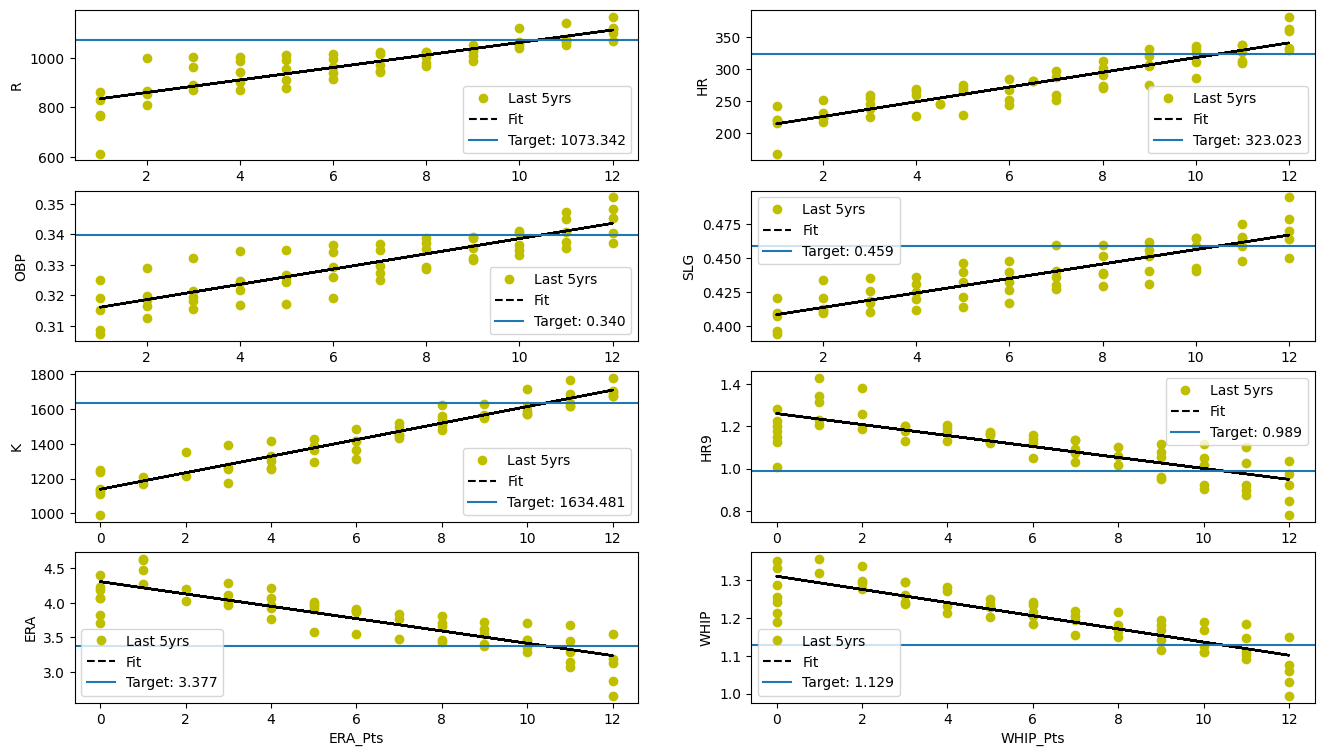

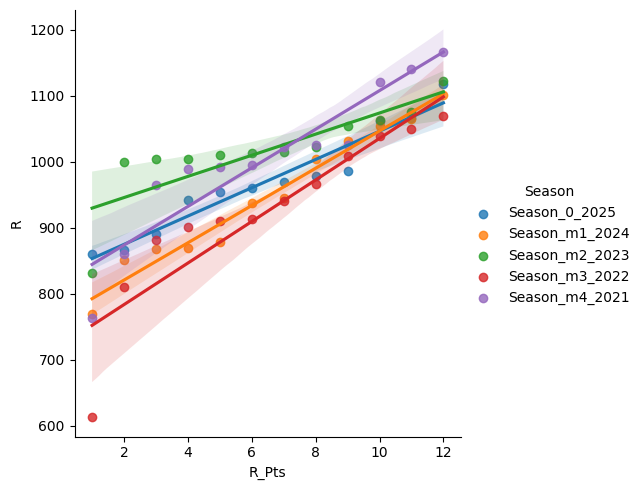

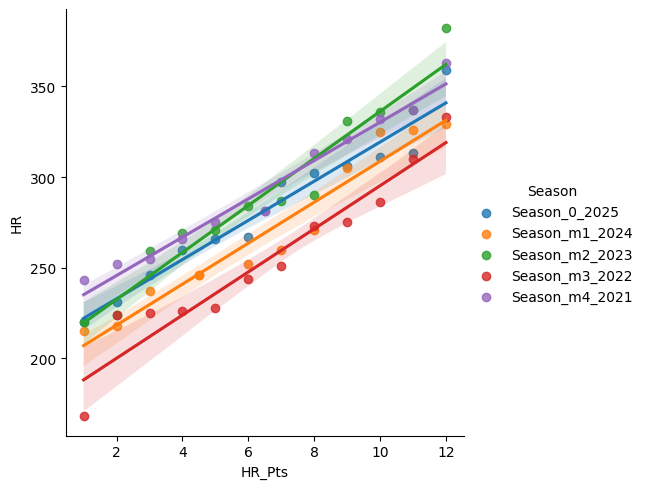

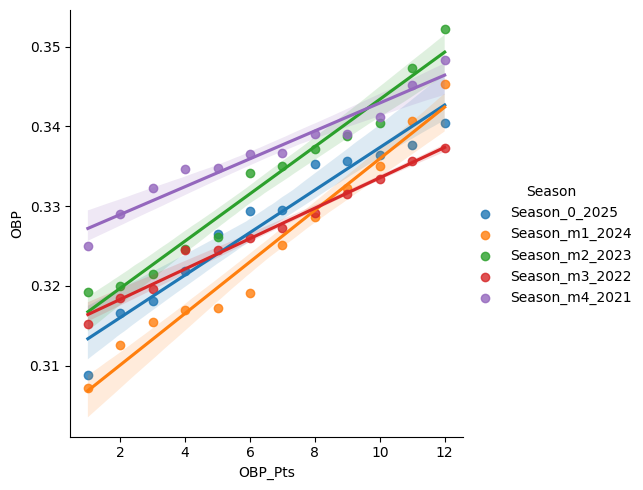

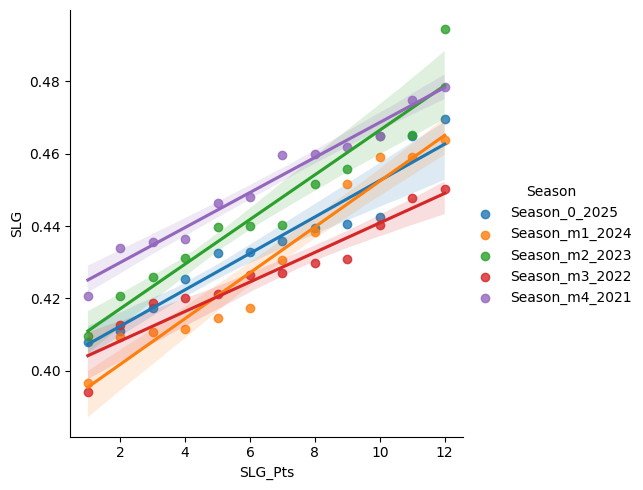

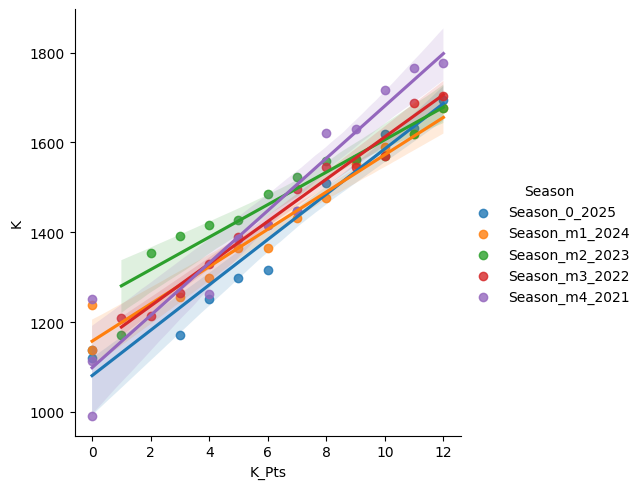

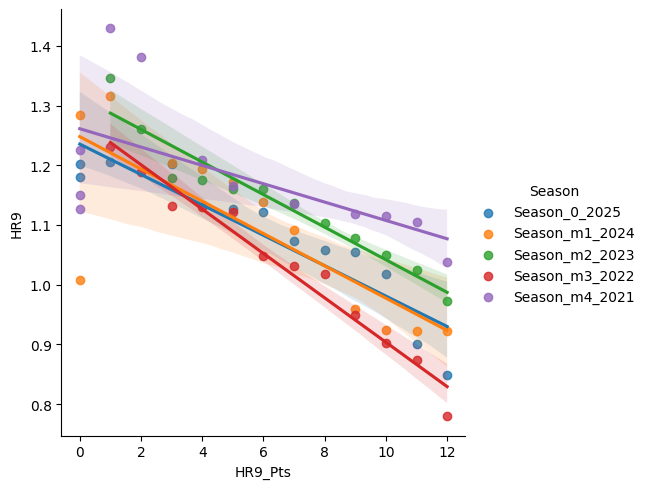

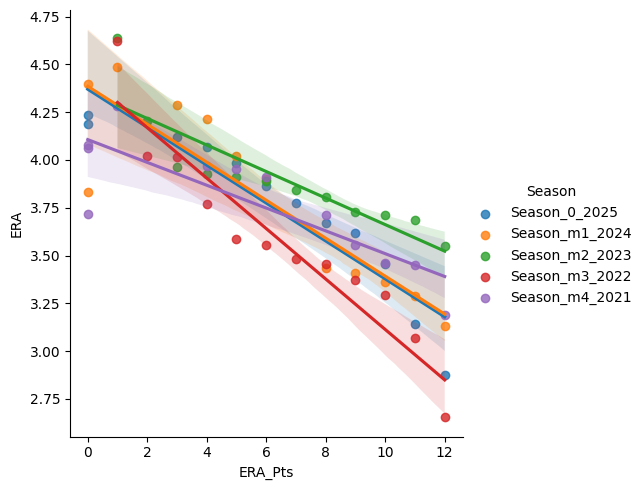

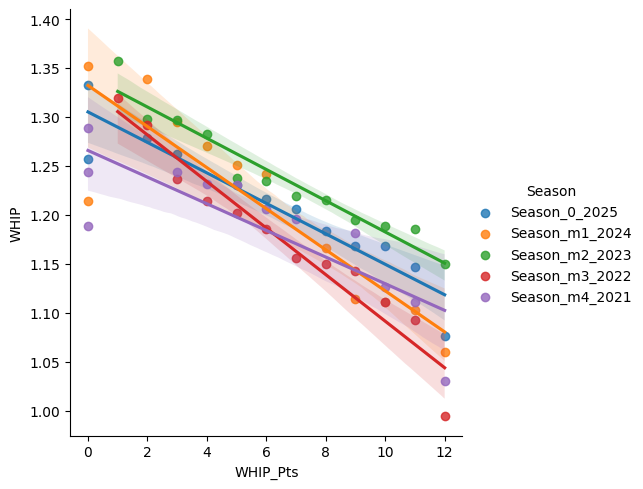

In [21]:
fig, axs = plt.subplots(int(len(Scoring_Categories)/2),2,figsize=(16,9))
SGP_Denom_dict = {}
Cat_target_dict = {'Target Pts': Avg_cat_pts_win}
for stat, this_ax in zip(Scoring_Categories, axs.reshape(-1)):
    print(this_ax)
    coef = np.polyfit(y=Stat_Ranks[stat],x=Stat_Ranks[f'{stat}_Pts'],deg=1)
    print(coef)
    poly1d_fn = np.poly1d(coef)  
    this_ax.plot(Stat_Ranks[f'{stat}_Pts'],Stat_Ranks[stat], 'yo',label='Last 5yrs')
    this_ax.set_xlabel(f'{stat}_Pts')
    this_ax.set_ylabel(stat)
    this_ax.plot(Stat_Ranks[f'{stat}_Pts'], poly1d_fn(Stat_Ranks[f'{stat}_Pts']), '--k',label='Fit') 

    sns.lmplot(data=Stat_Ranks, y=stat, x=f'{stat}_Pts', hue='Season')
    SGP_Denom_dict[stat] = coef[0]
    Cat_target_dict[stat] = poly1d_fn(Avg_cat_pts_win)
    this_ax.axhline(poly1d_fn(Avg_cat_pts_win),label=f'Target: {poly1d_fn(Avg_cat_pts_win):.3f}')
    this_ax.legend()
fig.show()

In [22]:
print(SGP_Denom_dict)

{'R': np.float64(25.28251748251743), 'HR': np.float64(11.508403361344515), 'OBP': np.float64(0.002503279720279701), 'SLG': np.float64(0.00528697202797202), 'K': np.float64(47.5227326545109), 'HR9': np.float64(-0.026016417074877514), 'ERA': np.float64(-0.08937283374192077), 'WHIP': np.float64(-0.017438135920127117)}


In [29]:
for key, value in Cat_target_dict.items():
    print(f'{key}: {value:.3f}')

Target Pts: 10.441
R: 1073.342
HR: 323.023
OBP: 0.340
SLG: 0.459
K: 1634.481
HR9: 0.989
ERA: 3.377
WHIP: 1.129


In [24]:
import json
with open(f"{curr_path}/{League_Name}/SGP_Denom_dict.json", 'w') as f:
    json.dump(SGP_Denom_dict, f)

with open(f"{curr_path}/{League_Name}/Target_Stats_dict.json", 'w') as f:
    json.dump(Cat_target_dict, f)

In [25]:
Stat_Ranks.columns

Index(['Team', 'R_Pts', 'HR_Pts', 'OBP_Pts', 'SLG_Pts', 'K_Pts', 'HR9_Pts',
       'ERA_Pts', 'WHIP_Pts', 'TOTAL', 'CHG', 'Season', 'Place', 'Mean', 'Std',
       'TEAM', 'G', 'R', 'HR', 'OBP', 'SLG', 'IP', 'K', 'HR9', 'ERA', 'WHIP'],
      dtype='str')

In [26]:
Stat_Ranks.groupby("Place")[['R_Pts', 'HR_Pts', 'OBP_Pts', 'SLG_Pts', 'K_Pts', 'HR9_Pts',
       'ERA_Pts', 'WHIP_Pts', 'TOTAL']].agg([np.median, np.std])

R_Pts           HR_Pts           OBP_Pts           SLG_Pts            \
      median       std median       std  median       std  median       std   
Place                                                                         
1.0     12.0  0.800000   10.0  1.326650    12.0  0.400000    11.0  2.416609   
2.0     11.0  0.816497   12.0  1.213352    10.0  1.795055    10.5  1.384437   
3.0      8.0  3.310589   10.0  1.777639     6.0  2.727636    10.0  2.315167   
4.0      6.0  1.720465    5.0  2.416609     6.0  1.166190     6.0  2.135416   
5.0      8.0  2.059126    9.0  1.326650     7.0  3.072458     8.0  2.154066   
6.0      7.0  2.114763    8.5  2.671870     8.0  2.910708     7.5  2.733537   
7.0      4.0  2.800000    5.0  2.315167     6.0  2.000000     4.0  2.607681   
8.0      6.0  1.290994    4.0  1.290994     7.0  3.685557     5.0  1.598611   
9.0      4.0  1.624808    4.5  1.714643     4.0  2.925748     4.0  3.187475   
10.0     2.0  0.489898    2.0  2.576820     2.0  3.429286     4.0  2.870540   
11.0     4.0  3.000000    2.5  0.500000     4.0  1.299038     2.5  1.118034   
12.0     3.0  0.942809    1.0  1.885618     2.0  0.816497     2.0  0.816497   

       K_Pts           HR9_Pts           ERA_Pts           WHIP_Pts            \
      median       std  median       std  median       std   median       std   
Place                                                                           
1.0     12.0  0.489898    11.0  0.748331    11.0  1.019804     11.0  0.400000   
2.0      9.0  2.236068     8.5  3.785939     9.5  1.490712      9.0  1.795055   
3.0     10.0  0.489898     8.0  2.561250     9.0  2.481935      8.0  2.332381   
4.0      9.0  2.000000     9.0  2.332381    10.0  1.414214      9.0  2.481935   
5.0      6.0  2.993326     7.0  4.427189     8.0  4.400000      8.0  4.019950   
6.0      5.5  1.490712     6.5  1.674979     4.0  1.067187      4.0  1.490712   
7.0      5.0  2.280351     9.0  4.261455     7.0  3.200000      7.0  3.006659   
8.0      6.0  1.374369     5.0  1.572330     5.5  1.105542      4.5  2.748737   
9.0      7.0  3.600000     4.0  2.870540     3.0  2.638181      5.0  1.959592   
10.0     0.0  3.919184     0.0  2.529822     0.0  2.712932      0.0  4.176123   
11.0     3.0  0.866025     1.0  0.866025     1.0  1.299038      1.5  0.829156   
12.0     0.0  0.942809     0.0  0.942809     0.0  0.942809      0.0  0.942809   

       TOTAL             
      median        std  
Place                    
1.0     90.0   4.604346  
2.0     76.5   6.155395  
3.0     67.0   3.072458  
4.0     61.0   3.411744  
5.0     60.0   7.909488  
6.0     51.0   5.416026  
7.0     46.0   4.963869  
8.0     40.5   5.597619  
9.0     36.0   8.218272  
10.0    28.0  10.632027  
11.0    20.0   2.861381  
12.0    12.0   0.942809

In [27]:
Stat_Ranks.groupby("Place")[['TOTAL', 'G', 'R', 'HR', 'OBP', 'SLG']].agg([np.median, np.std])

TOTAL                  G                   R                 HR  \
      median        std  median         std  median         std median   
Place                                                                    
1.0     90.0   4.604346  1944.0    0.400000  1102.0   30.235079  313.0   
2.0     76.5   6.155395  1915.5   59.804311  1091.5   41.443402  346.0   
3.0     67.0   3.072458  1854.0   42.234583  1000.0   38.410415  310.0   
4.0     61.0   3.411744  1843.0   36.379115   995.0   30.216552  273.0   
5.0     60.0   7.909488  1883.0   59.514704  1025.0   40.006999  297.0   
6.0     51.0   5.416026  1906.0   69.657296   993.5   48.364645  297.5   
7.0     46.0   4.963869  1891.0   44.095351   986.0   64.725884  271.0   
8.0     40.5   5.597619  1860.5   48.047719   984.0   40.022563  253.5   
9.0     36.0   8.218272  1863.0  104.106484   901.0   55.291952  246.0   
10.0    28.0  10.632027  1603.0   86.109233   831.0   36.245827  243.0   
11.0    20.0   2.861381  1859.5   86.484103   901.0   91.568281  228.0   
12.0    12.0   0.942809  1739.0  111.561642   868.0  125.714845  215.0   

                       OBP                 SLG            
             std    median       std    median       std  
Place                                                     
1.0    17.652195  0.345280  0.004201  0.448000  0.010974  
2.0    25.163907  0.336575  0.008164  0.467245  0.019495  
3.0    16.017490  0.332250  0.005609  0.450260  0.006056  
4.0    24.161126  0.329330  0.006704  0.430800  0.015903  
5.0    27.498364  0.328610  0.010066  0.439390  0.020286  
6.0    31.291195  0.334720  0.007177  0.445940  0.013258  
7.0    36.445027  0.329560  0.006996  0.425870  0.018180  
8.0    12.485547  0.335210  0.009019  0.426910  0.009239  
9.0    18.378248  0.329160  0.011121  0.425370  0.020876  
10.0   18.733926  0.324970  0.005950  0.432810  0.014214  
11.0   15.562374  0.320695  0.006503  0.414065  0.009204  
12.0   40.019440  0.315420  0.000632  0.410840  0.007873

In [28]:
Stat_Ranks.groupby("Place")[['TOTAL', 'IP', 'K', 'HR9', 'ERA', 'WHIP']].agg([np.median, np.std])

TOTAL                  IP                   K                   HR9  \
      median        std   median         std  median         std    median   
Place                                                                        
1.0     90.0   4.604346  1496.20   20.368839  1676.0   47.609243  0.973510   
2.0     76.5   6.155395  1486.15   63.058828  1591.0  114.808536  1.113525   
3.0     67.0   3.072458  1484.20   28.424609  1618.0   48.094074  1.058470   
4.0     61.0   3.411744  1500.00   44.649139  1590.0   70.283426  1.024740   
5.0     60.0   7.909488  1356.00  130.258426  1415.0  122.295707  1.091510   
6.0     51.0   5.416026  1380.00   56.238354  1415.5   96.373694  1.129230   
7.0     46.0   4.963869  1291.00   79.309152  1364.0   97.232505  1.077730   
8.0     40.5   5.597619  1390.10   48.327439  1389.0   58.065098  1.147520   
9.0     36.0   8.218272  1319.00  184.421810  1432.0  204.488044  1.131530   
10.0    28.0  10.632027  1223.00  144.783024  1138.0  174.530685  1.125920   
11.0    20.0   2.861381  1348.15   91.789447  1213.5   44.392426  1.273555   
12.0    12.0   0.942809  1233.10   61.778655  1214.0   50.611812  1.188460   

                      ERA                WHIP            
            std    median       std    median       std  
Place                                                    
1.0    0.060396  3.452560  0.352384  1.111260  0.063969  
2.0    0.152275  3.539485  0.278729  1.154665  0.050850  
3.0    0.065446  3.547400  0.259618  1.188680  0.074174  
4.0    0.088329  3.458160  0.286533  1.156050  0.060134  
5.0    0.157854  3.436470  0.374450  1.168160  0.061158  
6.0    0.032837  3.947830  0.223614  1.251010  0.031102  
7.0    0.194876  3.729520  0.333482  1.185230  0.044488  
8.0    0.089779  3.889425  0.141608  1.222115  0.050194  
9.0    0.041249  4.014900  0.141086  1.237500  0.007001  
10.0   0.073766  3.890540  0.221488  1.215590  0.049071  
11.0   0.059386  4.553930  0.231104  1.329165  0.035559  
12.0   0.047232  4.188860  0.154386  1.332860  0.025319